# Week 7 — Reinforcement Learning & Q-Learning

*A brief, hands-on introduction. We build a single idea — an agent that learns a behavioural rule from the rewards its actions earn — and watch it play a classic social dilemma, the Public Goods Game. This is the conceptual groundwork for this week's papers, where a reinforcement-learning agent is handed a far more powerful job: not playing the game, but **designing the rule everyone plays under**.*


## 1 · What is reinforcement learning?

Reinforcement learning (RL) is a model of **learning from experience**. The agent is *not* shown the right answer (that would be supervised learning) and is *not* handed a model of how the world works. It simply **acts, observes the reward, and adjusts** — doing more of what paid off and less of what didn't.

Four ingredients define any RL problem:

| Ingredient | Meaning | In today's game |
|---|---|---|
| **State** $s$ | what the agent observes before acting | how much the others contributed on average |
| **Action** $a$ | what the agent can do | how much *I* contribute |
| **Reward** $r$ | the feedback signal | my payoff this round |
| **Policy** $\pi$ | the rule mapping states to actions | "given what others do, how much do I give?" |

The agent improves its policy by repeating one simple loop:

```text
        +-------------------------------------------------+
        |                                                 |
        v                                                 |
   observe state  -->  choose action  -->  get reward + new state
        ^                                                 |
        |               update what you believe           |
        +----------------  about each action  <-----------+
```

For a social scientist, this is a model of **adaptive behaviour**: an agent groping toward a good strategy by trial and error — the way reinforcement models of human choice (Roth–Erev) describe people learning in repeated games. Today the agent learns *how much to contribute* in a public-goods game.


## 2 · Where this is going: a player today, a rule-setter next

In this notebook the RL agent is a **player inside the game**. It learns how to act under a fixed set of rules.

This week's papers (Köster, Tacchetti et al. 2024; Köster, Pîslar et al. 2025) flip the seat. There the RL agent does **not** play — it **designs the rule** (the redistribution mechanism) that humans then play under, and is rewarded by how well the resulting human behaviour scores on a welfare target. Same four ingredients; but the *action* is now "which institution to impose."

So the skill to build first is the one below: *what an RL agent is, and how the simplest version — Q-learning — actually learns.* Once that is intuitive, the chapter's move ("let the RL agent choose the rules") is a change of seat, not a new machine.


## 3 · The game: a Public Goods Game

We use one of the social sciences' canonical experiments.

- Each player receives an **endowment** (here, 20 tokens).
- Players simultaneously decide how much to **contribute** to a public pool.
- The pool is **multiplied** (here, 1.5×) and **split equally** among all players.
- Each player keeps what they didn't contribute, plus their share of the pool.

**The dilemma.** Individually, the best move is to **free-ride** — contribute 0 and live off others' contributions. Collectively, everyone is best off when **everyone contributes**. That tension is the whole point. Real-world instances: climate action, tax compliance, shared infrastructure, team effort.

Our Q-learning agent plays *one* seat at this table. Can it learn to navigate the dilemma?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style('whitegrid')
np.random.seed(42)

In [2]:
# Game parameters
ENDOWMENT = 20          # Initial tokens each player has
MULTIPLIER = 1.5        # How much contributions are multiplied
GROUP_SIZE = 4          # Number of players in the group

# Discretize contributions (actions)
# For simplicity, players can contribute in increments of 5
POSSIBLE_CONTRIBUTIONS = [0, 5, 10, 15, 20]
NUM_ACTIONS = len(POSSIBLE_CONTRIBUTIONS)

print("Public Goods Game Parameters:")
print(f"  Endowment: {ENDOWMENT} tokens")
print(f"  Multiplier: {MULTIPLIER}x")
print(f"  Group size: {GROUP_SIZE} players")
print(f"  Possible contributions: {POSSIBLE_CONTRIBUTIONS}")
print()
print("Example calculation:")
print("  If everyone contributes 10 tokens:")
print(f"    Total pool: 4 × 10 = 40 tokens")
print(f"    After multiplier: 40 × {MULTIPLIER} = {40 * MULTIPLIER} tokens")
print(f"    Each player receives: {40 * MULTIPLIER / GROUP_SIZE} tokens")
print(f"    Each player kept: {ENDOWMENT - 10} tokens")
print(f"    Final payoff: {ENDOWMENT - 10} + {40 * MULTIPLIER / GROUP_SIZE} = {ENDOWMENT - 10 + 40 * MULTIPLIER / GROUP_SIZE} tokens")

Public Goods Game Parameters:
  Endowment: 20 tokens
  Multiplier: 1.5x
  Group size: 4 players
  Possible contributions: [0, 5, 10, 15, 20]

Example calculation:
  If everyone contributes 10 tokens:
    Total pool: 4 × 10 = 40 tokens
    After multiplier: 40 × 1.5 = 60.0 tokens
    Each player receives: 15.0 tokens
    Each player kept: 10 tokens
    Final payoff: 10 + 15.0 = 25.0 tokens


In [3]:
def calculate_payoff(my_contribution, others_contributions):
    """
    Calculate payoff for a player in the Public Goods Game.
    
    Parameters:
    - my_contribution: how much I contribute
    - others_contributions: list of contributions from other players
    
    Returns:
    - payoff: tokens earned this round
    """
    # What I keep
    kept = ENDOWMENT - my_contribution
    
    # Total pool from all players
    total_pool = my_contribution + sum(others_contributions)
    
    # Multiply and divide equally
    multiplied_pool = total_pool * MULTIPLIER
    my_share = multiplied_pool / GROUP_SIZE
    
    # Total payoff
    payoff = kept + my_share
    
    return payoff

# Test the payoff function
print("Testing payoff function:")
print(f"  I contribute 0, others contribute [10, 10, 10]: {calculate_payoff(0, [10, 10, 10]):.2f} tokens")
print(f"  I contribute 10, others contribute [10, 10, 10]: {calculate_payoff(10, [10, 10, 10]):.2f} tokens")
print(f"  I contribute 10, others contribute [0, 0, 0]: {calculate_payoff(10, [0, 0, 0]):.2f} tokens")
print()
print("Notice: Contributing 0 (free-riding) gives the highest individual payoff!")
print("But if everyone does this, total payoff is lowest.")

Testing payoff function:
  I contribute 0, others contribute [10, 10, 10]: 31.25 tokens
  I contribute 10, others contribute [10, 10, 10]: 25.00 tokens
  I contribute 10, others contribute [0, 0, 0]: 13.75 tokens

Notice: Contributing 0 (free-riding) gives the highest individual payoff!
But if everyone does this, total payoff is lowest.


## 4 · States and actions

- **State** — the average contribution of the *other* players, discretised into bins. This is the agent's read of its social context.
- **Action** — how much the agent itself contributes: one of `[0, 5, 10, 15, 20]`.


In [4]:
# Discretize states (average contribution of others)
# We'll use bins: [0-5), [5-10), [10-15), [15-20], [20]
STATE_BINS = [0, 5, 10, 15, 20]
NUM_STATES = len(STATE_BINS)

def get_state_from_avg_contribution(avg_contribution):
    """
    Convert average contribution of others into a discrete state.
    """
    for i in range(len(STATE_BINS) - 1):
        if avg_contribution < STATE_BINS[i + 1]:
            return i
    return len(STATE_BINS) - 1

print("State representation:")
print(f"  Number of states: {NUM_STATES}")
print(f"  State bins: {STATE_BINS}")
print()
print("Examples:")
for avg in [0, 3, 7, 12, 18, 20]:
    state = get_state_from_avg_contribution(avg)
    print(f"  Average contribution {avg} → State {state}")

print()
print("Action representation:")
print(f"  Number of actions: {NUM_ACTIONS}")
print(f"  Actions: {POSSIBLE_CONTRIBUTIONS}")

State representation:
  Number of states: 5
  State bins: [0, 5, 10, 15, 20]

Examples:
  Average contribution 0 → State 0
  Average contribution 3 → State 0
  Average contribution 7 → State 1
  Average contribution 12 → State 2
  Average contribution 18 → State 3
  Average contribution 20 → State 4

Action representation:
  Number of actions: 5
  Actions: [0, 5, 10, 15, 20]


## 5 · The Q-table — the agent's memory

Everything the agent "knows" lives in one table. Each entry $Q(s,a)$ is its current estimate of the **expected payoff** of taking action $a$ in state $s$. Rows are states (what others do); columns are actions (what I could give).

```text
                 0      5      10     15     20
               +------+------+------+------+------+
Others: ~0-5   | Q₀₀  | Q₀₁  | Q₀₂  | Q₀₃  | Q₀₄  |
               +------+------+------+------+------+
Others: ~5-10  | Q₁₀  | Q₁₁  | Q₁₂  | Q₁₃  | Q₁₄  |  ← STATES
               +------+------+------+------+------+    (others' avg)
Others: ~10-15 | Q₂₀  | Q₂₁  | Q₂₂  | Q₂₃  | Q₂₄  |
               +------+------+------+------+------+
Others: ~15-20 | Q₃₀  | Q₃₁  | Q₃₂  | Q₃₃  | Q₃₄  |
               +------+------+------+------+------+
Others: ~20    | Q₄₀  | Q₄₁  | Q₄₂  | Q₄₃  | Q₄₄  |
               +------+------+------+------+------+

Each cell Qₛₐ stores the expected payoff of taking action a in state s
```

At the start every entry is 0 — the agent has experienced nothing yet. Learning *is* the process of filling this table in.


In [5]:
# Initialize Q-table
Q_table = np.zeros((NUM_STATES, NUM_ACTIONS))

print("Q-table initialized!")
print(f"Shape: {Q_table.shape} ({NUM_STATES} states × {NUM_ACTIONS} actions)")
print()
print("Initial Q-table:")
print(Q_table)
print()
print("All values start at 0. The agent hasn't learned anything yet!")

Q-table initialized!
Shape: (5, 5) (5 states × 5 actions)

Initial Q-table:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

All values start at 0. The agent hasn't learned anything yet!


## 6 · Choosing an action: ε-greedy (explore vs. exploit)

A learner faces a tension: **exploit** what looks best so far, or **explore** in case something better exists. The simplest rule is **ε-greedy**:

- with probability $\varepsilon$ → pick a **random** action (explore),
- with probability $1-\varepsilon$ → pick the **highest-Q** action (exploit).

Notice where the randomness comes from: it is **bolted on from the outside**. We return to this in §15 — it is the first thing that makes this agent unlike a human.


In [6]:
def choose_action(state, epsilon):
    """
    Choose action using epsilon-greedy policy.
    
    With probability epsilon: explore (random action)
    With probability (1-epsilon): exploit (best action from Q-table)
    """
    if np.random.random() < epsilon:
        # Explore: random action
        action_idx = np.random.randint(NUM_ACTIONS)
    else:
        # Exploit: best action
        action_idx = np.argmax(Q_table[state])
    
    return action_idx, POSSIBLE_CONTRIBUTIONS[action_idx]

print("Epsilon-greedy policy defined!")
print()
print("Example: choosing actions in state 2 (others average ~10) with epsilon=0.3")
for i in range(5):
    action_idx, contribution = choose_action(state=2, epsilon=0.3)
    print(f"  Trial {i+1}: Action {action_idx} (contribute {contribution} tokens)")

Epsilon-greedy policy defined!

Example: choosing actions in state 2 (others average ~10) with epsilon=0.3
  Trial 1: Action 0 (contribute 0 tokens)
  Trial 2: Action 0 (contribute 0 tokens)
  Trial 3: Action 0 (contribute 0 tokens)
  Trial 4: Action 0 (contribute 0 tokens)
  Trial 5: Action 2 (contribute 10 tokens)


## 7 · How learning happens: the Bellman update

After each round the agent nudges the relevant Q-value toward what it just experienced:

$$Q(s, a) \;\leftarrow\; Q(s, a) \;+\; \alpha\,\big[\,\underbrace{r + \gamma\,\max_{a'} Q(s', a')}_{\text{what it now estimates}} \;-\; \underbrace{Q(s, a)}_{\text{what it expected}}\,\big]$$

In plain language:

> **new estimate = old estimate + learning rate × surprise**,
> where *surprise* = (reward received + discounted value of where you landed) − (what you expected).

- $\alpha$ (**learning rate**) — how big a nudge each experience gives.
- $\gamma$ (**discount factor**) — how much the agent weighs future rounds against this one.
- $\max_{a'} Q(s',a')$ — the agent assumes it will act optimally *next* time.

That single line, applied thousands of times, is the entire learning algorithm.


In [7]:
def update_q_table(state, action_idx, reward, next_state, alpha, gamma):
    """
    Update Q-table using Bellman equation.
    """
    current_q = Q_table[state, action_idx]
    max_next_q = np.max(Q_table[next_state])
    
    # Bellman update
    new_q = current_q + alpha * (reward + gamma * max_next_q - current_q)
    
    Q_table[state, action_idx] = new_q

print("Q-learning update function defined!")

Q-learning update function defined!


### A concrete update, in *our* notation

Our indexing differs slightly from the textbook. Here $s_t$ is what you saw **entering** round $t$ — the others' contributions you observed last round — so the action you take in round 2 is keyed to the state $s_1$ you had just seen.

Concretely, the update that happens **before round 3** is:

$$Q_2(s_1, a_2) = (1-\alpha)\,Q_1(s_1, a_2) + \alpha\Big(r_2 + \gamma \max_a Q_1(s_2, a)\Big)$$

Reading it in our public-goods setup:

- After round 1 you observed $s_1 = (9, 9, 9)$.
- In round 2 you chose $a_2 = 5$.
- At the end of round 2 you observed $s_2 = (9, 9, 9)$ and collected reward $r_2$.
- Before round 3, you update the value of *taking action $a_2$ having seen $s_1$*.

So the transition is $(s_1, a_2) \rightarrow (r_2, s_2)$:

| role | symbol |
|------|--------|
| old state | $s_1$ |
| chosen action | $a_2$ |
| received reward | $r_2$ |
| newly observed state | $s_2$ |

This is fully consistent with Q-learning — only the **indexing convention** differs from the textbook $Q(s,a) \leftarrow \dots$ form.

In [8]:
# One concrete update, in our time-indexed notation (no side effects on Q_table)
s1 = [9, 9, 9]    # others' contributions observed in round 1
a2 = 5            # action chosen in round 2 (conditioned on the lagged state s1)
s2 = [9, 9, 9]    # others' contributions observed in round 2

r2 = calculate_payoff(a2, s2)          # reward earned in round 2
print(f"r2 = payoff(a2=5, others=(9,9,9)) = {r2:.1f} tokens")

# Illustrative estimates the table might hold partway through learning:
Q1_s1_a2 = 24.0                        # Q1(s1, a2): current belief
maxQ1_s2 = 28.0                        # max_a Q1(s2, a): best value at the newly observed state
alpha, gamma = 0.1, 0.9

Q2_s1_a2 = (1 - alpha) * Q1_s1_a2 + alpha * (r2 + gamma * maxQ1_s2)
print(f"Q2(s1,a2) = (1-{alpha})*{Q1_s1_a2} + {alpha}*({r2:.0f} + {gamma}*{maxQ1_s2}) = {Q2_s1_a2:.3f}")

r2 = payoff(a2=5, others=(9,9,9)) = 27.0 tokens
Q2(s1,a2) = (1-0.1)*24.0 + 0.1*(27 + 0.9*28.0) = 26.820


## 8 · The other players

To train one learner we need opponents to react to. We hard-code a small, recognisable mix drawn straight from the experimental public-goods literature: a **cooperator**, a **free-rider**, and a **conditional cooperator**. The agent never sees their types — only their average contribution (its state).


In [9]:
def simulate_other_players():
    """
    Simulate contributions from other players.
    Returns a list of contributions from the other GROUP_SIZE-1 players.
    """
    contributions = []
    
    # Player 1: Cooperator (contributes 15-20)
    contributions.append(np.random.choice([15, 20]))
    
    # Player 2: Free-rider (contributes 0-5)
    contributions.append(np.random.choice([0, 5]))
    
    # Player 3: Conditional cooperator (contributes around the average)
    # For simplicity, choose randomly but biased toward middle values
    contributions.append(np.random.choice([5, 10, 15]))
    
    return contributions

# Test the simulation
print("Simulating other players (5 rounds):")
for i in range(5):
    others = simulate_other_players()
    avg = np.mean(others)
    print(f"  Round {i+1}: {others} → Average: {avg:.2f}")

Simulating other players (5 rounds):
  Round 1: [np.int64(15), np.int64(0), np.int64(15)] → Average: 10.00
  Round 2: [np.int64(20), np.int64(0), np.int64(15)] → Average: 11.67
  Round 3: [np.int64(20), np.int64(0), np.int64(10)] → Average: 10.00
  Round 4: [np.int64(20), np.int64(5), np.int64(10)] → Average: 11.67
  Round 5: [np.int64(20), np.int64(5), np.int64(5)] → Average: 10.00


## 9 · Train the agent

Now let the agent play many rounds: observe the others' average → pick a contribution (ε-greedy) → collect its payoff → apply the Bellman update. Repeat a few thousand times and watch the Q-table fill in.


In [10]:
# Reset Q-table
Q_table = np.zeros((NUM_STATES, NUM_ACTIONS))

# Hyperparameters
alpha = 0.1          # Learning rate
gamma = 0.9          # Discount factor
epsilon = 0.2        # Exploration rate
num_episodes = 2000  # Number of rounds to play

# Tracking
payoffs = []
contributions_made = []
states_visited = []

print("Training the Q-learning agent...\n")

for episode in range(num_episodes):
    # Simulate other players' contributions
    others_contributions = simulate_other_players()
    avg_others = np.mean(others_contributions)
    
    # Get current state
    state = get_state_from_avg_contribution(avg_others)
    
    # Choose action
    action_idx, my_contribution = choose_action(state, epsilon)
    
    # Calculate reward (payoff)
    reward = calculate_payoff(my_contribution, others_contributions)
    
    # Simulate next round to get next state
    # (In reality, this would be the next round, but for training we simulate)
    next_others = simulate_other_players()
    next_avg_others = np.mean(next_others)
    next_state = get_state_from_avg_contribution(next_avg_others)
    
    # Update Q-table
    update_q_table(state, action_idx, reward, next_state, alpha, gamma)
    
    # Track results
    payoffs.append(reward)
    contributions_made.append(my_contribution)
    states_visited.append(state)
    
    # Print progress
    if (episode + 1) % 400 == 0:
        recent_payoff = np.mean(payoffs[-400:])
        recent_contrib = np.mean(contributions_made[-400:])
        print(f"Episode {episode + 1}/{num_episodes}")
        print(f"  Average payoff (last 400): {recent_payoff:.2f} tokens")
        print(f"  Average contribution (last 400): {recent_contrib:.2f} tokens")

print("\nTraining complete!")

Training the Q-learning agent...

Episode 400/2000
  Average payoff (last 400): 27.73 tokens
  Average contribution (last 400): 5.24 tokens
Episode 800/2000
  Average payoff (last 400): 28.12 tokens
  Average contribution (last 400): 4.90 tokens
Episode 1200/2000
  Average payoff (last 400): 28.26 tokens
  Average contribution (last 400): 4.86 tokens
Episode 1600/2000
  Average payoff (last 400): 28.29 tokens
  Average contribution (last 400): 4.71 tokens
Episode 2000/2000
  Average payoff (last 400): 27.70 tokens
  Average contribution (last 400): 5.33 tokens

Training complete!


## 10 · Did it learn?

Two windows on the same run: the agent's **payoff** over time, and the **contribution** it chooses over time. Watch whether contributions drift up (toward cooperation) or down (toward free-riding) as the table settles.


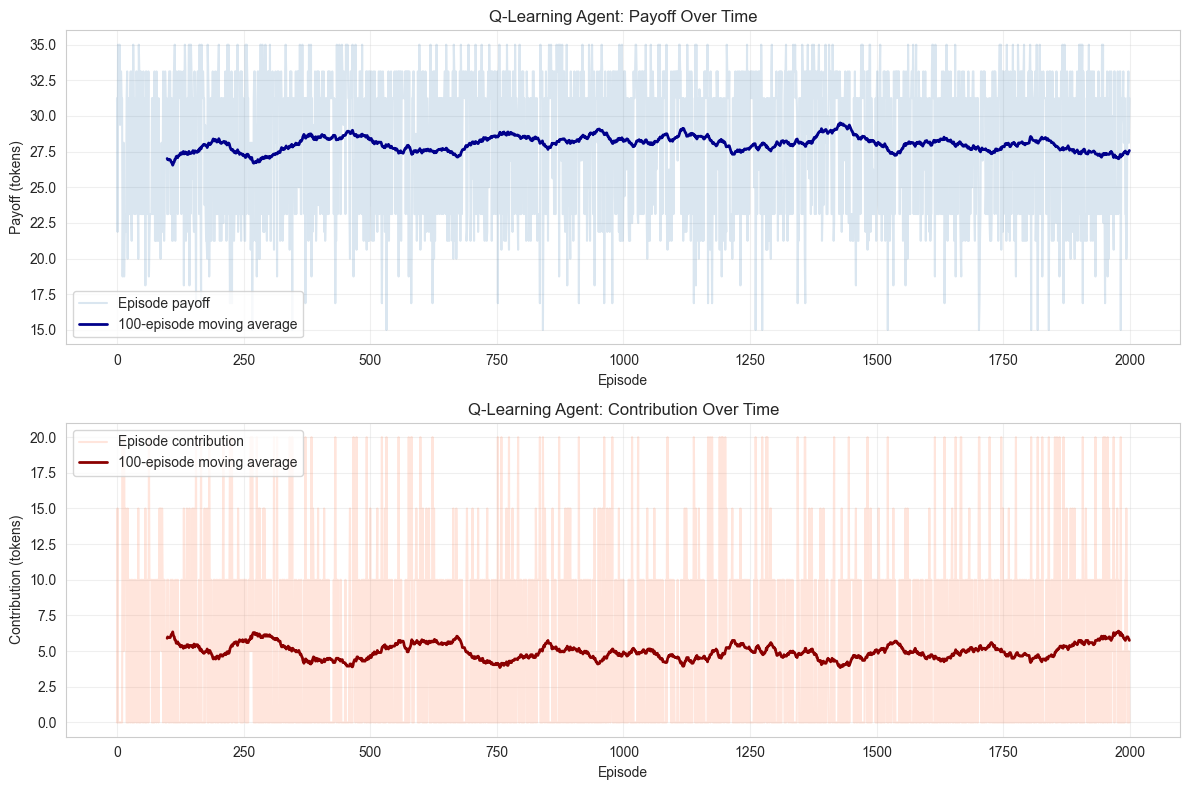

What patterns do you see?
Is the agent learning to cooperate or free-ride?


In [11]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Payoffs over time
window = 100
moving_avg_payoff = np.convolve(payoffs, np.ones(window)/window, mode='valid')

axes[0].plot(payoffs, alpha=0.2, label='Episode payoff', color='steelblue')
axes[0].plot(range(window-1, len(payoffs)), moving_avg_payoff, 
             linewidth=2, label=f'{window}-episode moving average', color='darkblue')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Payoff (tokens)')
axes[0].set_title('Q-Learning Agent: Payoff Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Contributions over time
moving_avg_contrib = np.convolve(contributions_made, np.ones(window)/window, mode='valid')

axes[1].plot(contributions_made, alpha=0.2, label='Episode contribution', color='coral')
axes[1].plot(range(window-1, len(contributions_made)), moving_avg_contrib, 
             linewidth=2, label=f'{window}-episode moving average', color='darkred')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Contribution (tokens)')
axes[1].set_title('Q-Learning Agent: Contribution Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("What patterns do you see?")
print("Is the agent learning to cooperate or free-ride?")

## 11 · The learned Q-table

The filled-in table, as a heatmap. Greener cells are higher expected payoff. Reading across a row tells you which contribution the agent now believes is best given what the others are doing.


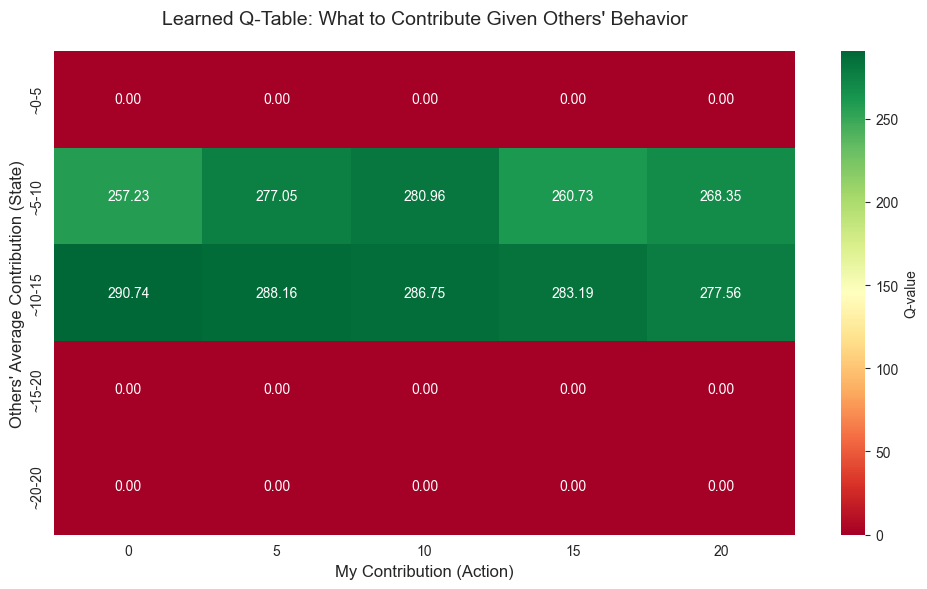

Reading the Q-table:
  - Each row is a STATE (what others are contributing on average)
  - Each column is an ACTION (what I could contribute)
  - Higher values (greener) mean better expected payoff
  - The agent has learned which contribution maximizes payoff in each situation!


In [12]:
# Display Q-table as a heatmap
plt.figure(figsize=(10, 6))

# Create labels
state_labels = [f'~{STATE_BINS[i]}-{STATE_BINS[i+1] if i < len(STATE_BINS)-1 else STATE_BINS[i]}' 
                for i in range(NUM_STATES)]
action_labels = [f'{c}' for c in POSSIBLE_CONTRIBUTIONS]

sns.heatmap(Q_table, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=action_labels, yticklabels=state_labels,
            cbar_kws={'label': 'Q-value'})

plt.xlabel('My Contribution (Action)', fontsize=12)
plt.ylabel('Others\' Average Contribution (State)', fontsize=12)
plt.title('Learned Q-Table: What to Contribute Given Others\' Behavior', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("Reading the Q-table:")
print("  - Each row is a STATE (what others are contributing on average)")
print("  - Each column is an ACTION (what I could contribute)")
print("  - Higher values (greener) mean better expected payoff")
print("  - The agent has learned which contribution maximizes payoff in each situation!")

## 12 · The learned policy

The **policy** is just the best action in each row — the agent's answer to "given what others contribute, how much do I give?" We print it, then plot it.


In [13]:
# Extract best action for each state
policy = np.argmax(Q_table, axis=1)
best_contributions = [POSSIBLE_CONTRIBUTIONS[i] for i in policy]

print("Learned Policy (greedy, no exploration):\n")
print("  Others' Avg    →    My Best Contribution")
print("  " + "="*45)
for i, state_label in enumerate(state_labels):
    print(f"  {state_label:15s} →    {best_contributions[i]:2d} tokens")

print()
print("Interpretation:")
if best_contributions[0] == 0 and best_contributions[-1] == 0:
    print("  The agent learned to FREE-RIDE (contribute 0) regardless of others' behavior.")
    print("  This maximizes individual payoff but leads to collective failure!")
elif best_contributions[0] < best_contributions[-1]:
    print("  The agent learned CONDITIONAL COOPERATION.")
    print("  It contributes more when others contribute more!")
elif all(c == max(POSSIBLE_CONTRIBUTIONS) for c in best_contributions):
    print("  The agent learned to COOPERATE fully, always contributing maximum.")
    print("  This is pro-social but might not maximize individual payoff.")
else:
    print("  The agent learned a mixed strategy based on others' behavior.")

Learned Policy (greedy, no exploration):

  Others' Avg    →    My Best Contribution
  ~0-5            →     0 tokens
  ~5-10           →    10 tokens
  ~10-15          →     0 tokens
  ~15-20          →     0 tokens
  ~20-20          →     0 tokens

Interpretation:
  The agent learned to FREE-RIDE (contribute 0) regardless of others' behavior.
  This maximizes individual payoff but leads to collective failure!


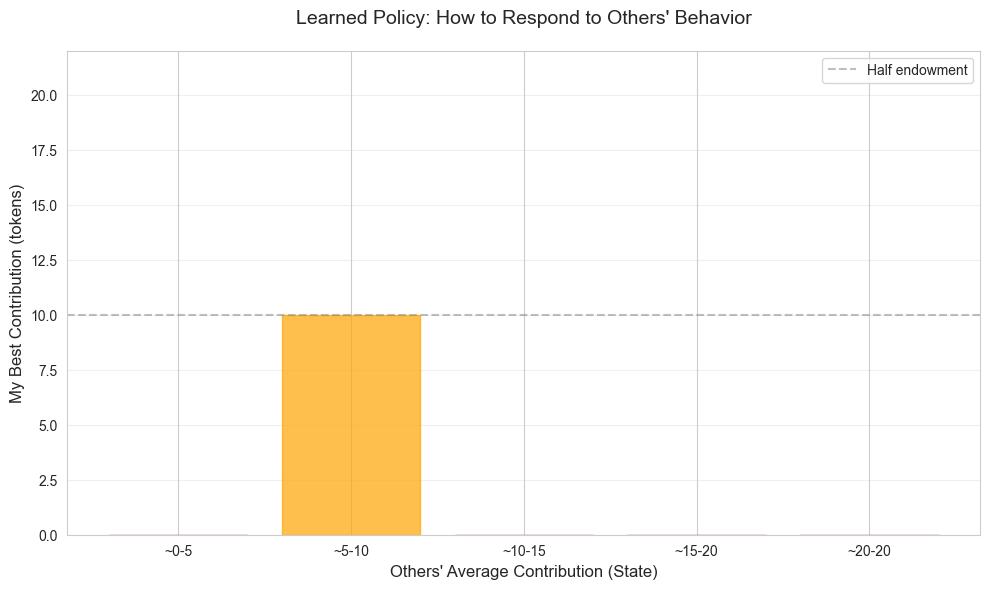

In [14]:
plt.figure(figsize=(10, 6))

x = np.arange(len(state_labels))
bars = plt.bar(x, best_contributions, color='steelblue', alpha=0.7, edgecolor='black')

# Color bars based on contribution level
colors = ['darkred' if c == 0 else 'orange' if c <= 10 else 'green' for c in best_contributions]
for bar, color in zip(bars, colors):
    bar.set_color(color)
    bar.set_alpha(0.7)

plt.xlabel('Others\' Average Contribution (State)', fontsize=12)
plt.ylabel('My Best Contribution (tokens)', fontsize=12)
plt.title('Learned Policy: How to Respond to Others\' Behavior', fontsize=14, pad=20)
plt.xticks(x, state_labels, rotation=0)
plt.ylim(0, ENDOWMENT + 2)
plt.grid(True, alpha=0.3, axis='y')

# Add reference line
plt.axhline(y=ENDOWMENT/2, color='gray', linestyle='--', alpha=0.5, label='Half endowment')
plt.legend()

plt.tight_layout()
plt.show()

## 13 · Stress-testing the policy

Finally, freeze learning and drop the trained agent into specific groups — all cooperators, all free-riders, a mixed table — to see how its fixed rule pays off against each.


In [15]:
def test_policy_against_strategy(other_contributions, num_rounds=100):
    """
    Test the learned policy against a specific group strategy.
    """
    total_payoff = 0
    my_contributions = []
    
    for _ in range(num_rounds):
        # Get state
        avg_others = np.mean(other_contributions)
        state = get_state_from_avg_contribution(avg_others)
        
        # Choose best action (no exploration)
        action_idx = np.argmax(Q_table[state])
        my_contribution = POSSIBLE_CONTRIBUTIONS[action_idx]
        
        # Calculate payoff
        payoff = calculate_payoff(my_contribution, other_contributions)
        
        total_payoff += payoff
        my_contributions.append(my_contribution)
    
    return total_payoff / num_rounds, np.mean(my_contributions)

# Test against different group types
print("Testing learned policy against different group types:\n")

scenarios = [
    ("All cooperators", [20, 20, 20]),
    ("All free-riders", [0, 0, 0]),
    ("Mixed group", [0, 10, 20]),
    ("Moderate cooperators", [10, 10, 10]),
    ("High cooperators", [15, 15, 15]),
]

for scenario_name, others in scenarios:
    avg_payoff, avg_contrib = test_policy_against_strategy(others)
    print(f"{scenario_name}:")
    print(f"  Others contribute: {others} (avg: {np.mean(others):.1f})")
    print(f"  My average contribution: {avg_contrib:.2f} tokens")
    print(f"  My average payoff: {avg_payoff:.2f} tokens")
    print()

Testing learned policy against different group types:

All cooperators:
  Others contribute: [20, 20, 20] (avg: 20.0)
  My average contribution: 0.00 tokens
  My average payoff: 42.50 tokens

All free-riders:
  Others contribute: [0, 0, 0] (avg: 0.0)
  My average contribution: 0.00 tokens
  My average payoff: 20.00 tokens

Mixed group:
  Others contribute: [0, 10, 20] (avg: 10.0)
  My average contribution: 0.00 tokens
  My average payoff: 31.25 tokens

Moderate cooperators:
  Others contribute: [10, 10, 10] (avg: 10.0)
  My average contribution: 0.00 tokens
  My average payoff: 31.25 tokens

High cooperators:
  Others contribute: [15, 15, 15] (avg: 15.0)
  My average contribution: 0.00 tokens
  My average payoff: 36.88 tokens



## 14 · What did the agent learn?

Pulling the threads together:

- **Q-learning discovers a strategy** for a social dilemma without ever being told the rules of good behaviour — only by maximising its own reward.
- Whether that strategy is **free-riding, full cooperation, or conditional cooperation** depends on the game parameters, the other players, and the reward structure.
- In a pure-payoff world, free-riding usually wins — which is precisely why the *design of the rule* (next week) matters.

**Discussion**

1. What strategy did your agent settle on, and why that one?
2. Raise `MULTIPLIER` to 2.0 and retrain — does cooperation become more attractive?
3. What happens to group welfare if **every** seat is a Q-learner like this one?
4. The reward here is pure self-interest. What would you change to model someone who also cares about fairness?


## 15 · The next step: making Q-learning behave like a person

This agent is a clean optimiser, but it is **not** a model of a human in two specific ways — and both are fixable.

1. **Its randomness is external.** ε-greedy makes the agent either perfectly greedy or perfectly random. People are neither: they pick *better* actions *more often*, in a graded way. The fix is to replace `max` + ε-greedy with a **softmax / conditional-choice-probability (CCP)** policy governed by a *temperature* $\tau$ that dials bounded rationality smoothly from near-perfect to near-random.

2. **It only values its own tokens.** People also weigh fairness, reciprocity, and inequity. The fix is to add **latent social-preference terms** $\theta$ to the reward — turning the payoff the agent maximises into a *behavioural* utility.

Together these turn standard Q-learning into **soft, behaviourally-adjusted Q-learning**. The companion notebook **`7_qlearning_behavioral.ipynb`** works through exactly this: the soft Q-function, why `log-sum-exp` replaces `max`, CCP vs. ε-greedy, and even how the hidden $\theta$ can be *recovered* from observed choices (the latent-intentions identification result).

And then the chapter's question becomes available: once you can model how people behave *under a rule*, you can let an RL agent **choose the rule itself** — the mechanism-design move in Köster et al. that this week is about.
